# Часть 1: K-Means
## Кластеризация исполнителей по жанрам

В этом задании вы попробуете кластеризовать исполнителей по жанрам на основе данных о прослушивании.

В матрице sample_matrix по строкам стоят пользователи, а по столбцам - исполнители.

Для каждой пары (пользователь,исполнитель) в таблице стоит число - доля (процент) прослушивания этого исполнителя выбранным пользователем.

## Импорт библиотек, загрузка данных

In [30]:
import pandas as pd

In [31]:
ratings = pd.read_excel("https://github.com/evgpat/edu_stepik_rec_sys/blob/main/datasets/sample_matrix.xlsx?raw=true", engine='openpyxl')

In [32]:
ratings.head()

,user,the beatles,radiohead,deathcab for cutie,coldplay,modest mouse,sufjan stevens,dylan. bob,red hot clili peppers,pink fluid,...,municipal waste,townes van zandt,curtis mayfield,jewel,lamb,michal w. smith,群星,agalloch,meshuggah,yellowcard
0,0,NaN,0.020417,NaN,NaN,NaN,NaN,NaN,0.030496,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,NaN,0.184962,0.024561,NaN,NaN,0.136341,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,NaN,NaN,0.028635,NaN,NaN,NaN,0.024559,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,0.043529,0.086281,0.034590,0.016712,0.015935,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Задание

Транспонируем матрицу ratings, чтобы по строкам стояли исполнители.

In [33]:
ratings = ratings.T

In [34]:
ratings

,0,1,2,3,4,5,6,7,8,9,...,4990,4991,4992,4993,4994,4995,4996,4997,4998,4999
user,0.000000,1.000000,2.000000,3.0,4.000000,5.000000,6.0,7.0,8.000000,9.000000,...,4990.000000,4991.0,4992.000000,4993.000000,4994.000000,4995.000000,4996.0,4997.000000,4998.0,4999.000000
the beatles,NaN,NaN,NaN,NaN,0.043529,NaN,NaN,NaN,0.093398,0.017621,...,NaN,NaN,0.121169,0.038168,0.007939,0.017884,NaN,0.076923,NaN,NaN
radiohead,0.020417,0.184962,NaN,NaN,0.086281,0.006322,NaN,NaN,NaN,0.019156,...,0.017735,NaN,NaN,NaN,0.011187,NaN,NaN,NaN,NaN,NaN
deathcab for cutie,NaN,0.024561,0.028635,NaN,0.034590,NaN,NaN,NaN,NaN,0.013349,...,0.121344,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.027893
coldplay,NaN,NaN,NaN,NaN,0.016712,NaN,NaN,NaN,NaN,NaN,...,0.217175,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
michal w. smith,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
群星,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
agalloch,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
meshuggah,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Выкиньте строку под названием `user`.

In [35]:
# ваш код здесь
ratings = ratings.drop('user', axis=0)

In [36]:
ratings.shape

(1000, 5000)

Заполните пропуски нулями.

In [37]:
# ваш код здесь
ratings = ratings.fillna(0)

Нормализуйте данные при помощи `normalize`.

In [38]:
from sklearn.preprocessing import normalize

# ваш код здесь
ratings_norm = normalize(ratings)

Примените KMeans с 5ю кластерами на преобразованной матрице (сделайте fit, а затем вычислите кластеры при помощи predict).

In [39]:
from sklearn.cluster import KMeans

# ваш код здесь
kmeans = KMeans(n_clusters=5, random_state=42)
ratings_kmeans = kmeans.fit_predict(ratings_norm)

Выведите на экран центры кластеров (центроиды)

In [40]:
# ваш код здесь
centroids = kmeans.cluster_centers_
centroids

array([[ 1.67830066e-03, -4.33680869e-19,  1.21266299e-04, ...,
         1.08420217e-18,  0.00000000e+00, -8.67361738e-19],
       [ 1.88589225e-03,  1.06654937e-04,  8.09463797e-04, ...,
         2.68938484e-03,  0.00000000e+00,  1.19757379e-03],
       [ 3.55821439e-04,  1.44240237e-04,  1.73721732e-03, ...,
         1.59066890e-04,  5.16646974e-03,  4.29001462e-04],
       [-1.30104261e-18,  1.60551391e-03,  1.92730597e-03, ...,
         8.36063816e-03,  0.00000000e+00, -1.08420217e-18],
       [ 2.14071913e-03,  1.93800900e-03,  1.67549440e-03, ...,
         3.78204679e-04,  1.58093924e-03,  3.39174746e-03]],
      shape=(5, 5000))

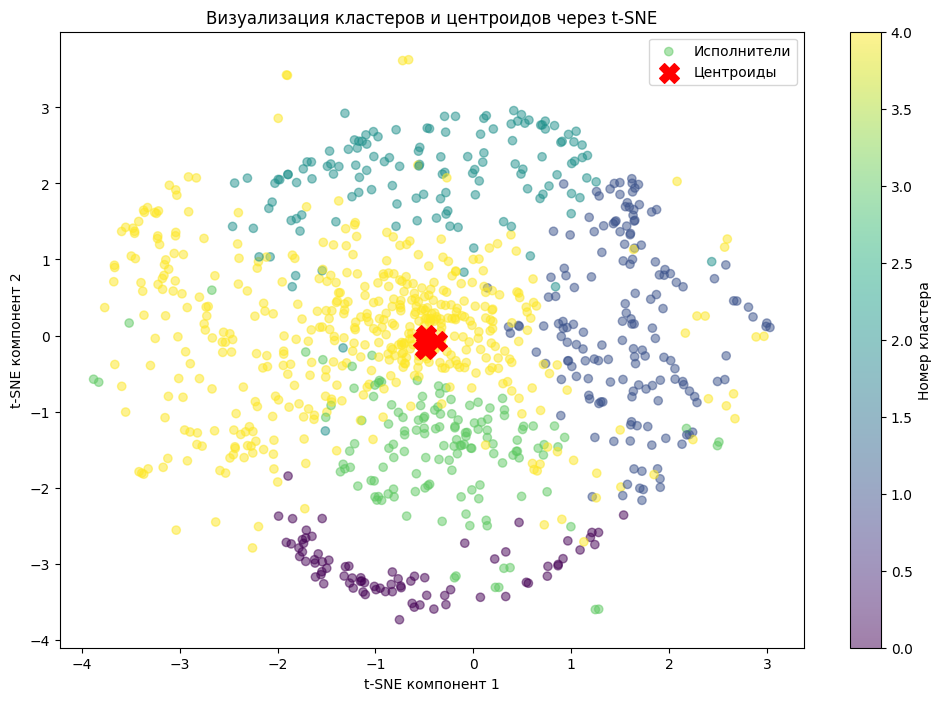

In [53]:
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import normalize

everything = np.vstack([ratings_norm, centroids])

tsne = TSNE(n_components=2, perplexity=30, random_state=42, init='pca', learning_rate='auto')

reduced_data = tsne.fit_transform(everything)

points_2d = reduced_data[:-5]
centroids_2d = reduced_data[-5:]

plt.figure(figsize=(12, 8))
scatter = plt.scatter(points_2d[:, 0], points_2d[:, 1], c=ratings_kmeans, cmap='viridis', alpha=0.5, label='Исполнители')
plt.scatter(centroids_2d[:, 0], centroids_2d[:, 1], c='red', marker='X', s=200, label='Центроиды')
plt.title('Визуализация кластеров и центроидов через t-SNE')
plt.xlabel('t-SNE компонент 1')
plt.ylabel('t-SNE компонент 2')
plt.legend()
plt.colorbar(scatter, label='Номер кластера')
plt.show()

Для каждого кластера найдем топ-10 исполнителей, наиболее близких к центроидам соотвествующего кластера.

Схожесть исполнителей будем считать по косинусной мере (spatial.distance.cosine).

Вычислите расстояние между "the beatles" и "coldplay". Ответ округлите до сотых.


In [49]:
from scipy import spatial

# ваш код здесь
dist = spatial.distance.cosine(ratings.loc['the beatles'], ratings.loc['coldplay'])
round(dist,2)

np.float64(0.9)

Ниже для вашего удобства написана функция, принимающая на вход:
* np.array points - все точки кластера
* pt - центроид кластера
* K = 10 - число
Функция возвращает K индексов объектов (строк в массиве points), ближайших к центроиду.

In [42]:
def pClosest(points, pt, K=10):
    ind = [i[0] for i in sorted(enumerate(points), key=lambda x: spatial.distance.cosine(x[1], pt))]

    return ind[:K]

Примените функцию pClosest (или придумайте свой подход) и выведите для каждого кластера названия топ-10 исполнителей, ближайших к центроиду.

In [50]:
# ваш код здесь
for i in range(len(centroids)):
    print(f'Кластер {i}:')
    indexes = pClosest(ratings_norm, centroids[i], K=10)
    names = ratings.index[indexes]

    for j,k in enumerate(names,1):
        print(j,k)
    print('\n')

Кластер 0:
1 nas
2 jay-z
3 kanye west
4 lupe the gorilla
5 a tribe called quest
6 the roots featuring d'angelo
7 gangstarr
8 little brother
9 lil' wayne
10 murs and 9th wonder


Кластер 1:
1 fall out boy
2 the all-americian rejects
3 paramore
4 kelly clarkson
5 john mayer
6 the fray
7 maroon5
8 dashboard confesssional
9 somethings corporate
10 coldplay


Кластер 2:
1 brand new
2 blink-182
3 alkaline trio
4 against me!
5 underoath
6 descendents
7 new found glory
8 less than jake
9 thrice
10 chiodos


Кластер 3:
1 the beatles
2 the rolling stones
3 dylan. bob
4 who
5 led zeppelin.
6 miles davis.
7 simon and garfunkel
8 young, neil
9 pink fluid
10 velvet underground


Кластер 4:
1 radiohead
2 the arcade fire
3 the shins
4 sufjan stevens
5 belle and sebastian
6 broken social scene
7 the pixies
8 animal collective
9 modest mouse
10 spoon




# Часть 2: сравнение алгоритмов кластеризации

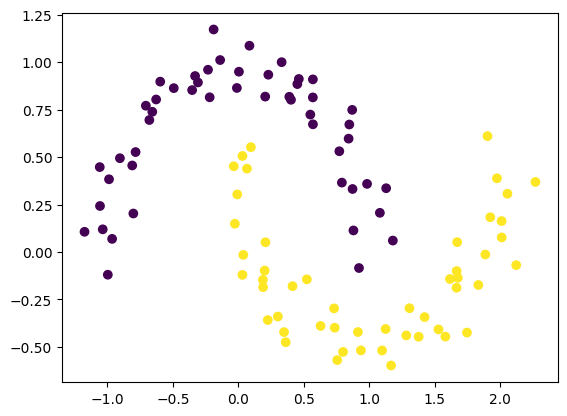

In [56]:
from matplotlib import pyplot as plt
from sklearn.datasets import make_moons

data = make_moons(n_samples=100, noise=0.1, random_state=42)

x = data[0]
y = data[1]

plt.scatter(X[:,0], X[:,1], c=y)

Далее вы попробуете разные кластеризации для поиска кластеров. Также замеряйте время работы каждого метода.

Попробуйте найти кластеры при помощи KMeans

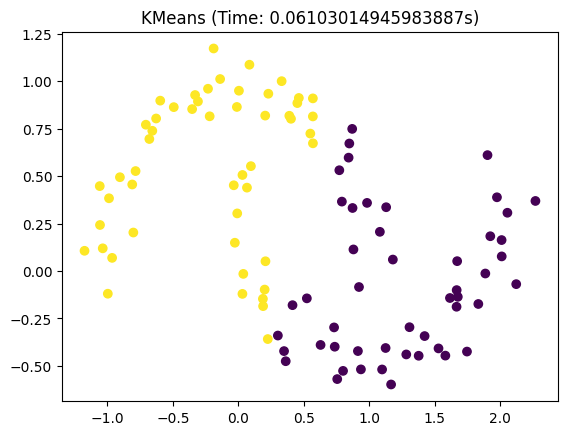

In [57]:
# ваш код здесь
from sklearn.cluster import KMeans
import time

start = time.time()
kmeans = KMeans(n_clusters=2).fit(x)
kmeans_time = time.time() - start

plt.scatter(X[:,0], X[:,1], c=kmeans.labels_)
plt.title(f"KMeans (Time: {kmeans_time}s)")
plt.show()

## Quiz

Подберите $\varepsilon$ и min_samples в DBSCAN, чтобы наилучшим образом найти кластеры.
Ищите гиперпараметры из диапазонов:
* eps in [0.05, 0.1, 0.2, 0.28, 0.3, 0.32]
* min_samples in [4, 5, 6, 7]

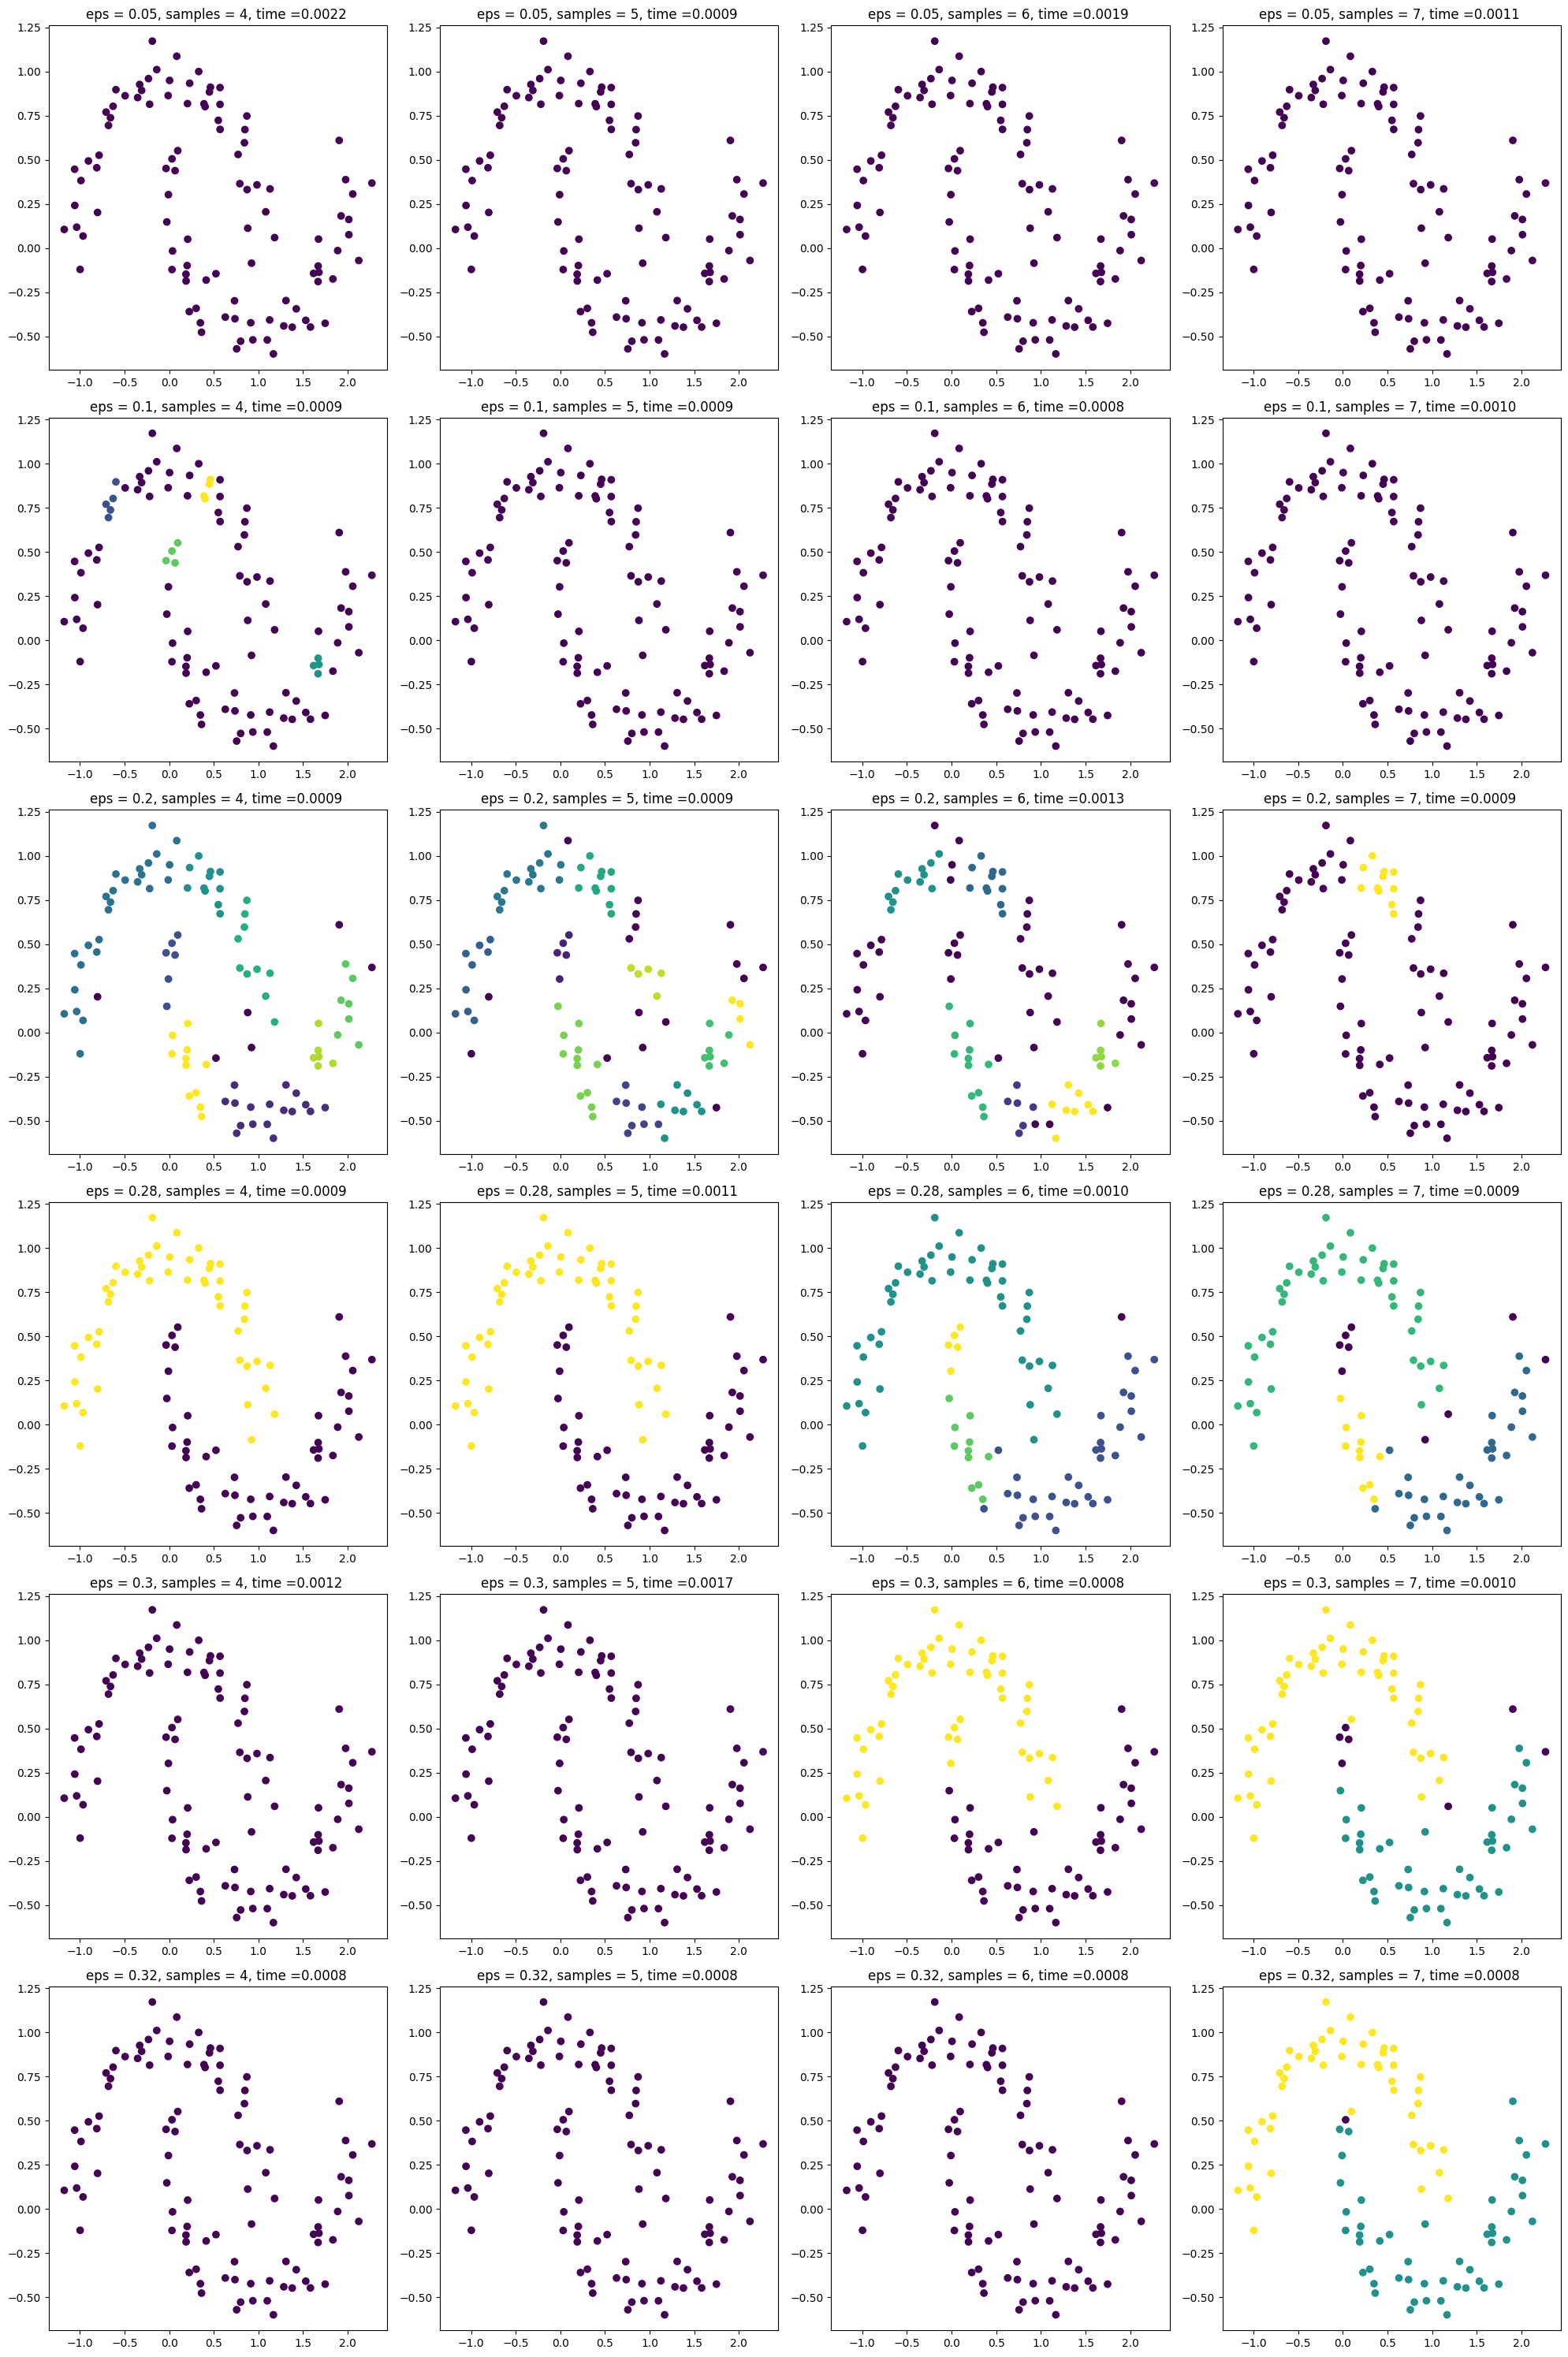

In [72]:
# ваш код здесь
from sklearn.cluster import DBSCAN

plt.figure(figsize=(20,30))
i=1
for e in [0.05, 0.1, 0.2, 0.28, 0.3, 0.32]:
    for s in [4, 5, 6, 7]:
        start = time.time()
        dbscan = DBSCAN(eps=e, min_samples=s).fit(x)
        dbscan_time = round(time.time() - start,4)

        plt.subplot(6, 4, i)
        plt.scatter(x[:,0],x[:,1],c=dbscan.labels_)
        plt.title('eps = {}, samples = {}, time ={:.4f} '.format(e,s, dbscan_time))
        i+=1
plt.tight_layout()
plt.show()

## Quiz

Используйте иерархическую кластеризацию для поиска кластеров.
Задайте в методе 2 кластера. Подберите гиперпараметр linkage из списка ['ward', 'complete', 'average', 'single'], дающий наилучший результат.

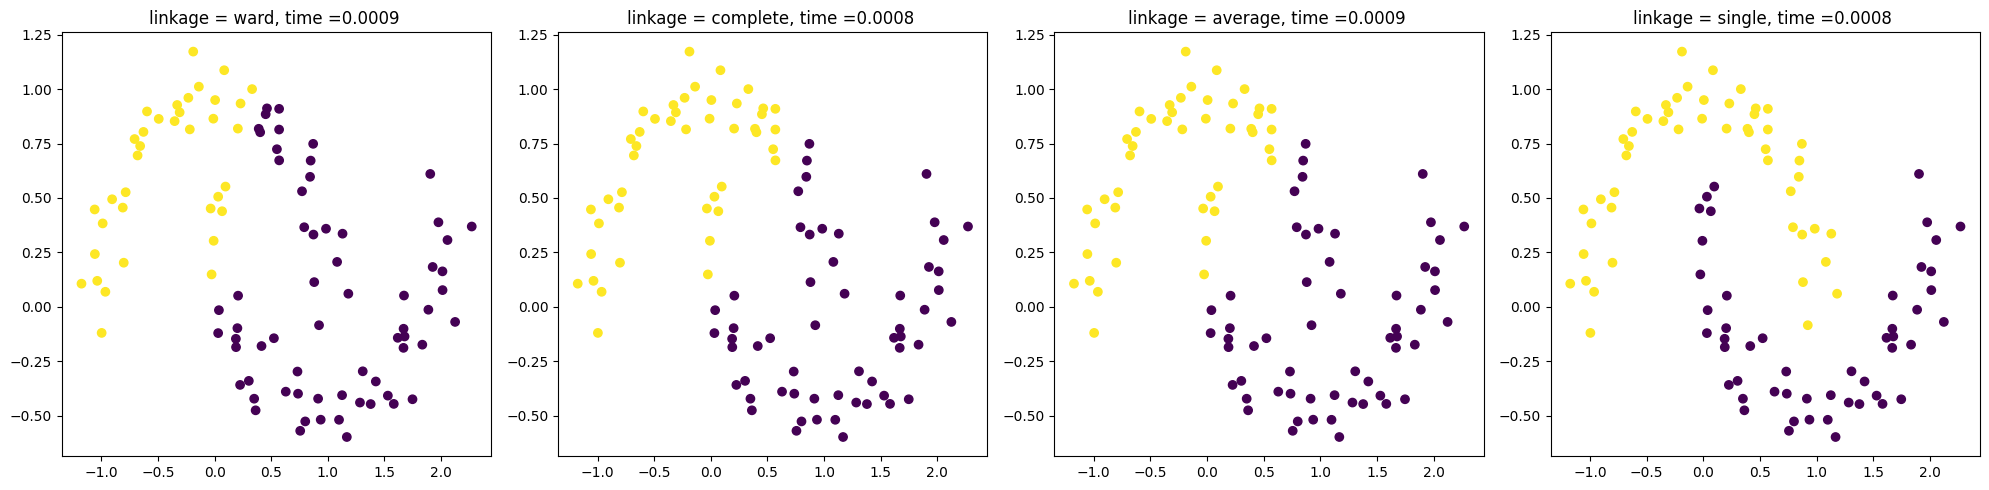

In [78]:
from sklearn.cluster import AgglomerativeClustering

# ваш код здесь
i = 1 
plt.figure(figsize=(20, 5))
for l in ['ward', 'complete', 'average', 'single']:
    start = time.time()
    agg = AgglomerativeClustering(n_clusters=2, linkage=l).fit(x)
    agg_time = time.time()- start

    plt.subplot(1, 4, i)
    plt.scatter(x[:,0],x[:,1],c=agg.labels_)
    plt.title('linkage = {}, time ={:.4f} '.format(l, agg_time))
    i+=1
plt.tight_layout()
plt.show()

## Quiz

Попробуйте найти кластеры при помощи спектральной кластеризации.
Задайте 2 кластера, affinity='nearest_neighbors', random_state=42. Подберите гиперпараметр n_neighbors из диапазона [1,2,...,19], чтобы добиться наилучшего результата.

c:\Users\arato\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:324: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
c:\Users\arato\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:324: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
c:\Users\arato\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:324: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
c:\Users\arato\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:324: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


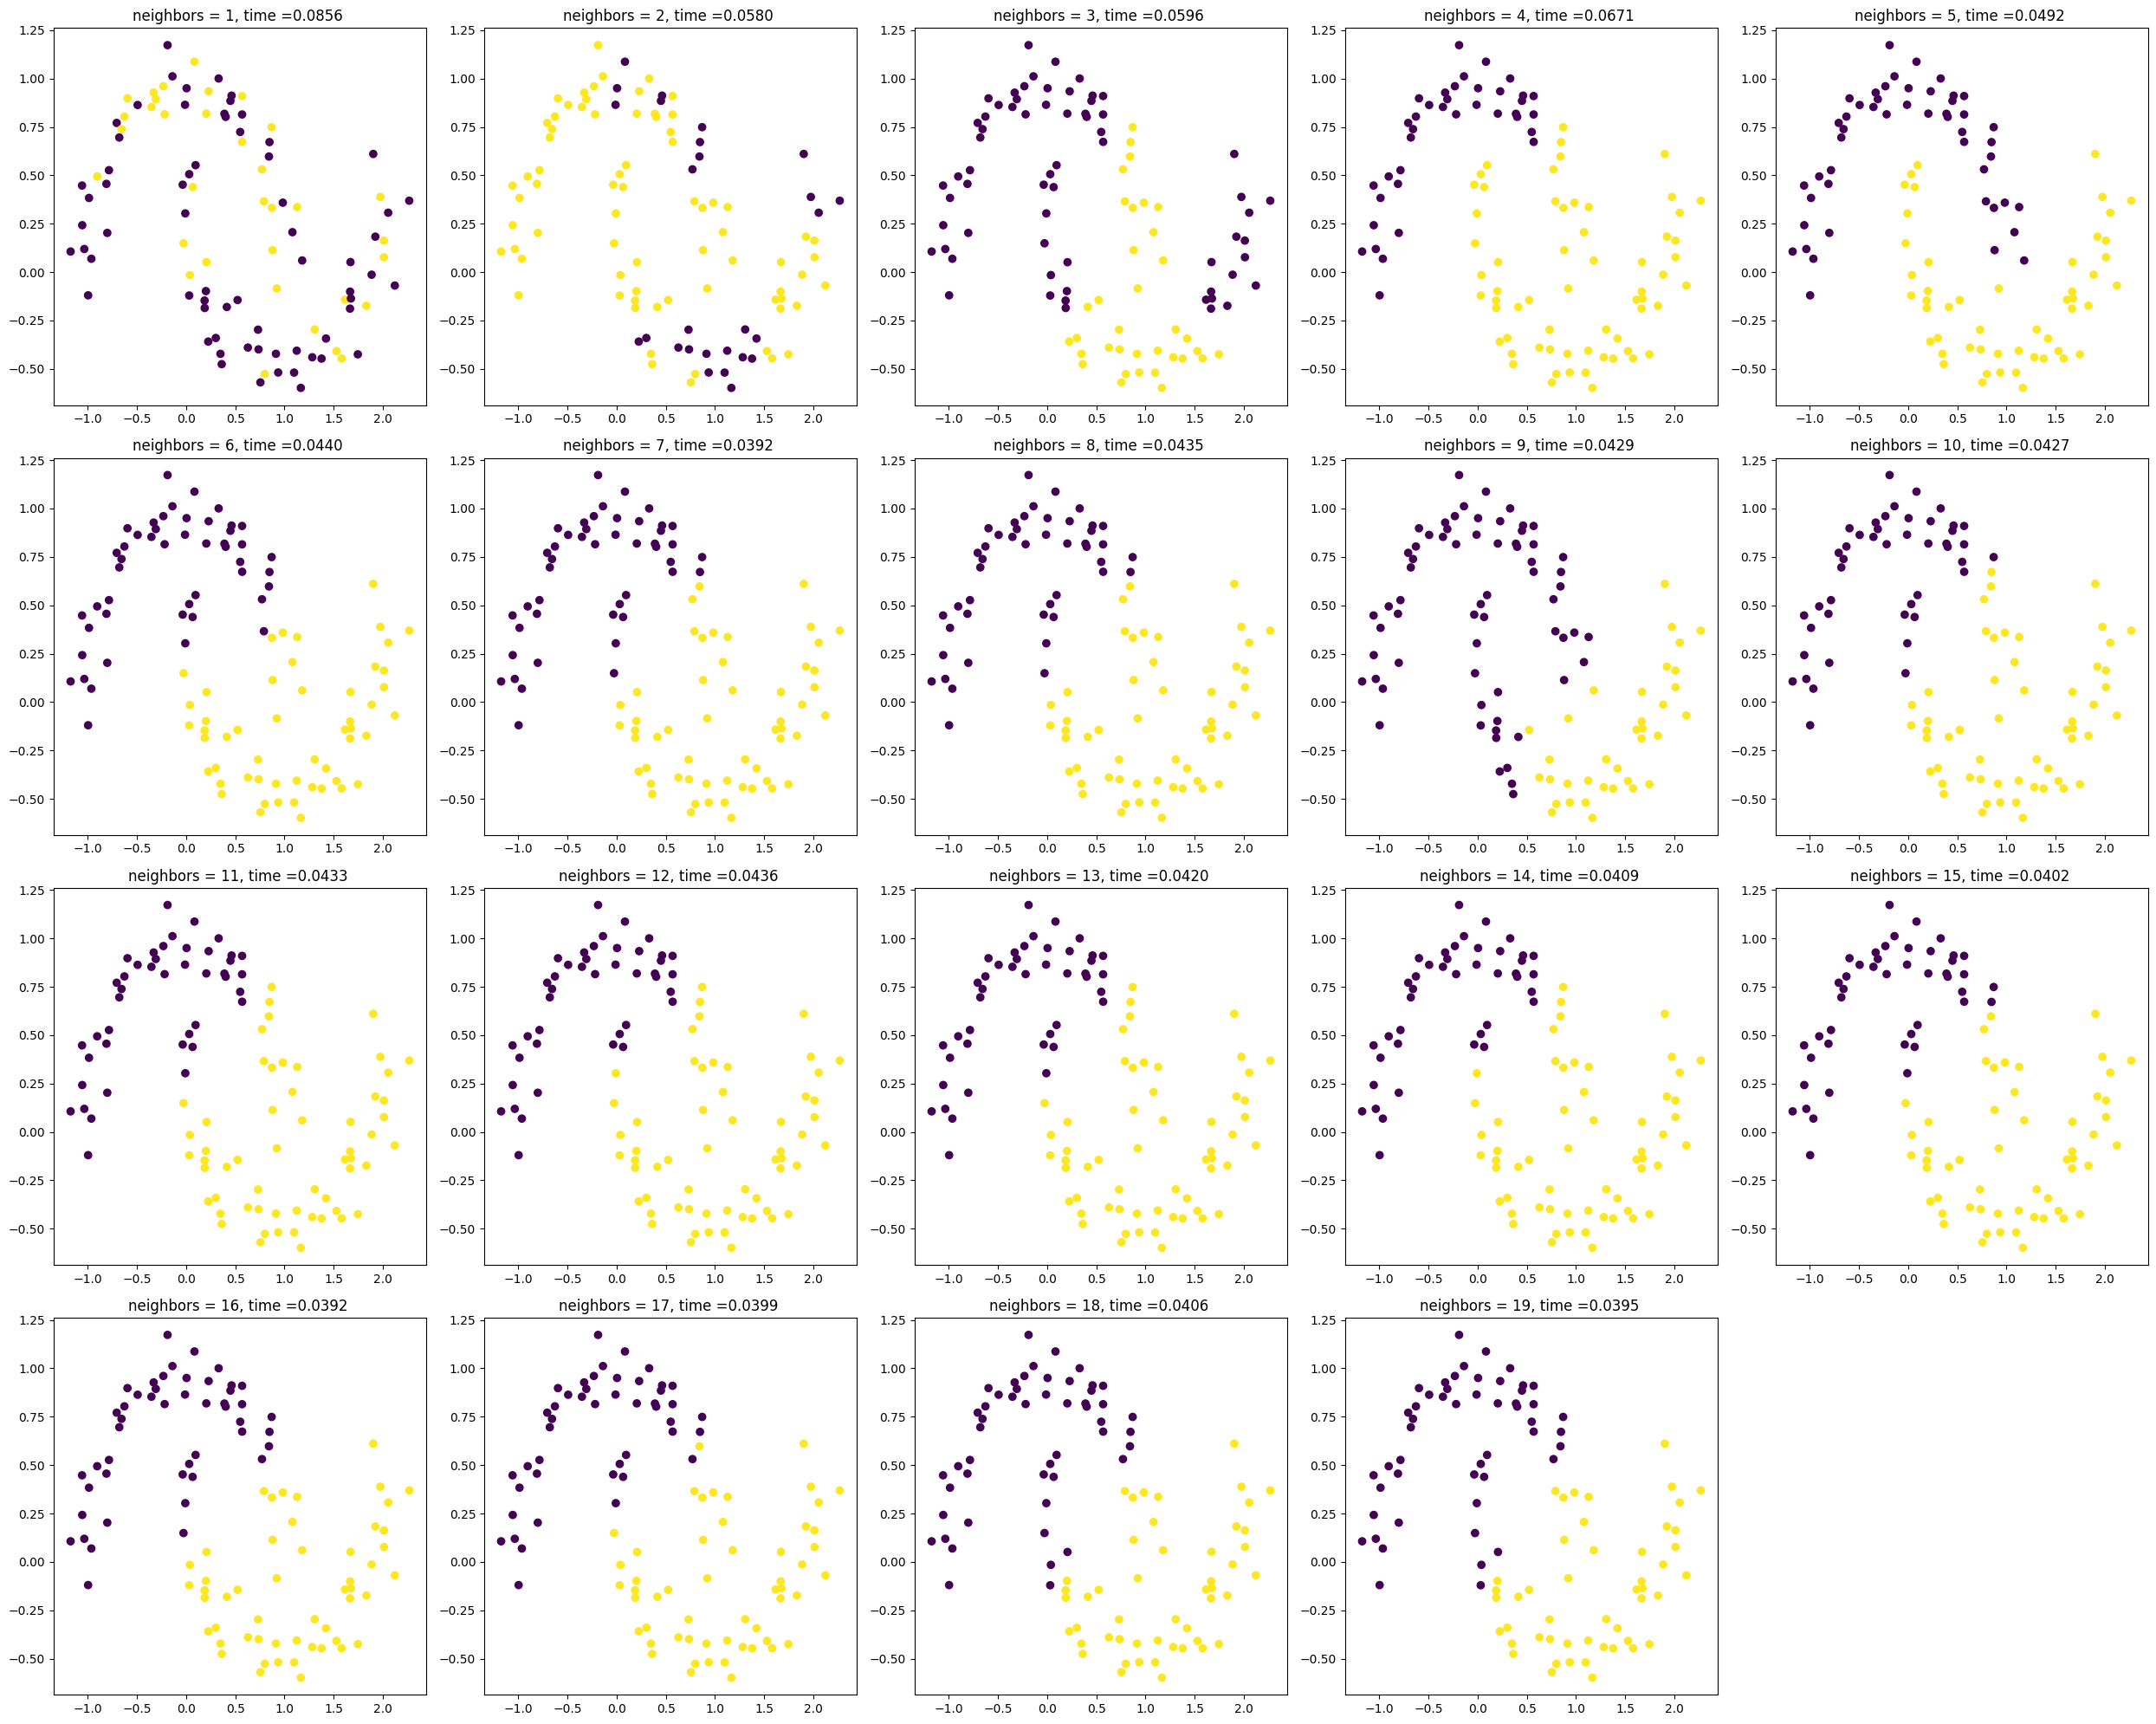

In [85]:
# ваш код здесь
from sklearn.cluster import SpectralClustering

i=1
plt.figure(figsize=(25,20))
for n in np.arange(1,20):
    start = time.time()
    spectre = SpectralClustering(n_clusters=2, affinity='nearest_neighbors', random_state=42, n_neighbors=n).fit(x)
    spectre_time = time.time() - start

    plt.subplot(4,5, i)
    plt.scatter(x[:,0], x[:,1], c=spectre.labels_)
    plt.title('neighbors = {}, time ={:.4f} '.format(n, spectre_time))
    i+=1
plt.tight_layout()
plt.show()

## Quiz

Сделайте выводы: какой метод сработал лучше других? какой метод сработал быстрее? есть ли метод, наилучший и по качеству, и по времени одновременно?

In [ ]:
plt.subplot(3,1,1)
plt